<a href="https://colab.research.google.com/github/aniilkeles/DeepLearningNotes/blob/main/Pytorch_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [50]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/06-study_hours_grades.csv')

In [51]:
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [53]:
X = torch.tensor(df['study_hours'].values,dtype = torch.float32).unsqueeze(1)
y = torch.tensor(df['grade'].values,dtype = torch.float32).unsqueeze(1)

In [54]:
X.shape

torch.Size([50, 1])

In [55]:
X.ndim

2

In [56]:
X

tensor([[3.7454],
        [9.5071],
        [7.3199],
        [5.9866],
        [1.5602],
        [1.5599],
        [0.5808],
        [8.6618],
        [6.0111],
        [7.0807],
        [0.2058],
        [9.6991],
        [8.3244],
        [2.1234],
        [1.8182],
        [1.8340],
        [3.0424],
        [5.2476],
        [4.3195],
        [2.9123],
        [6.1185],
        [1.3949],
        [2.9214],
        [3.6636],
        [4.5607],
        [7.8518],
        [1.9967],
        [5.1423],
        [5.9241],
        [0.4645],
        [6.0754],
        [1.7052],
        [0.6505],
        [9.4889],
        [9.6563],
        [8.0840],
        [3.0461],
        [0.9767],
        [6.8423],
        [4.4015],
        [1.2204],
        [4.9518],
        [0.3439],
        [9.0932],
        [2.5878],
        [6.6252],
        [3.1171],
        [5.2007],
        [5.4671],
        [1.8485]])

In [67]:
train_split = int(len(X)*0.8)
X_train , y_train = X[:train_split] , y[:train_split]
X_test , y_test = X[train_split:] , y[train_split:]

In [68]:
len(X_train) , len(X_test)

(40, 10)

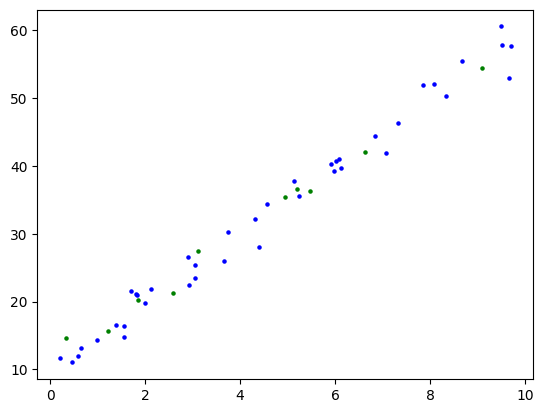

In [69]:
plt.scatter(X_train,y_train,c="b",s=5,label="Train Dataset")
plt.scatter(X_test,y_test,c="g",s=5,label="Test Dataset")
plt.show()

In [70]:
import torch.nn as nn
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_layer = nn.Linear(in_features=1,out_features=1) # nn.Linear(in_features,out_features) alır bu in_features ve out_features kaç tane girdi gelicek kaç tane çıktı olucak onu söyleriz.

  def forward(self,x:torch.Tensor)->torch.Tensor:
    return self.linear_layer(x)

In [78]:
torch.manual_seed(42)
model = LinearRegressionModel()
model = torch.compile(model)

In [79]:
model

OptimizedModule(
  (_orig_mod): LinearRegressionModel(
    (linear_layer): Linear(in_features=1, out_features=1, bias=True)
  )
)

In [80]:
model.state_dict()

OrderedDict([('_orig_mod.linear_layer.weight', tensor([[0.7645]])),
             ('_orig_mod.linear_layer.bias', tensor([0.8300]))])

In [81]:
# training işlemine geçmeden loss function ve optimizer belirlenir
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(params=model.parameters(),lr=0.01)

In [82]:
epochs = 120

for epoch in range(epochs):
  model.train()

  y_pred = model(X_train)

  loss = loss_fn(y_pred,y_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()

  with torch.inference_mode():
    test_pred = model(X_test)
    test_loss = loss_fn(test_pred,y_test)

  if epoch % 5 == 0:
    print(f"Epoch : {epoch}, Train Loss : {loss}, Test Loss : {test_loss}")

Epoch : 0, Train Loss : 965.6339721679688, Test Loss : 160.62022399902344
Epoch : 5, Train Loss : 22.257577896118164, Test Loss : 27.251602172851562
Epoch : 10, Train Loss : 21.13695526123047, Test Loss : 25.89261245727539
Epoch : 15, Train Loss : 20.168928146362305, Test Loss : 24.743696212768555
Epoch : 20, Train Loss : 19.254438400268555, Test Loss : 23.6547908782959
Epoch : 25, Train Loss : 18.390506744384766, Test Loss : 22.621475219726562
Epoch : 30, Train Loss : 17.574350357055664, Test Loss : 21.640789031982422
Epoch : 35, Train Loss : 16.803316116333008, Test Loss : 20.709945678710938
Epoch : 40, Train Loss : 16.07491683959961, Test Loss : 19.826316833496094
Epoch : 45, Train Loss : 15.386789321899414, Test Loss : 18.987407684326172
Epoch : 50, Train Loss : 14.736712455749512, Test Loss : 18.190872192382812
Epoch : 55, Train Loss : 14.122581481933594, Test Loss : 17.434463500976562
Epoch : 60, Train Loss : 13.54240608215332, Test Loss : 16.716089248657227
Epoch : 65, Train Los

In [83]:
X_train.shape
# dtype hatası genelde pytorchta alınır bunun önüne geçmek için train test split kısmında dtype ı belirtmek mantıklı torch.float32 kullanılır
# shape hatası da genelde pytorchta alınır mesela yukarıdaki örnekte olduğu gibi 1 girdi bekliyor ama benim şuan X_train.shape im 40 yani bunu 40 kolon gibi algılıyor ama halbukü 40 satır 1 kolon var
# burda bu sorunu çözmek için shape im (40,1) olması lazım bunuda yapabilmek için unsqueeze kullanarak 1 boyut ekleyerek bunu düzeltebiliriz
# linear.layer defaultu 32 bit floattır.

torch.Size([40, 1])

In [85]:
X_train.shape

torch.Size([40, 1])

In [86]:
model.state_dict()

OrderedDict([('_orig_mod.linear_layer.weight', tensor([[5.6578]])),
             ('_orig_mod.linear_layer.bias', tensor([5.7629]))])

In [87]:
model.eval()
with torch.inference_mode():
  y_preds = model(X_test)

In [88]:
y_preds

tensor([[12.6677],
        [33.7793],
        [ 7.7086],
        [57.2109],
        [20.4043],
        [43.2474],
        [23.3991],
        [35.1876],
        [36.6950],
        [16.2217]])

In [89]:
y_test

tensor([[15.6626],
        [35.4731],
        [14.6752],
        [54.4295],
        [21.3220],
        [42.1226],
        [27.4164],
        [36.6609],
        [36.2760],
        [20.2693]])

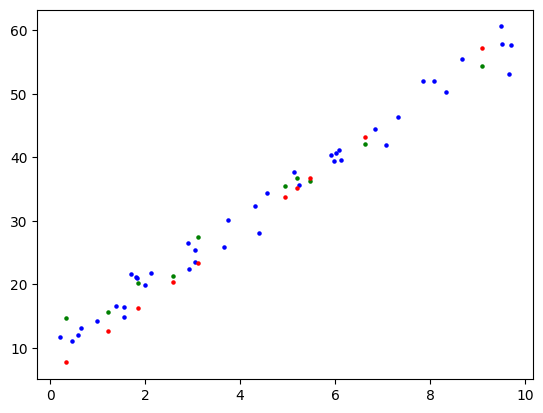

In [90]:
plt.scatter(X_train,y_train,c="b",s=5,label="Train Dataset")
plt.scatter(X_test,y_test,c="g",s=5,label="Test Dataset")
plt.scatter(X_test,y_preds,c="r",s=5,label="Predictions")
plt.show()